# EDA + Model Training for Student Performance Dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('D:\data shravani\Student_Performance.csv')
df.head()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\cs\AppData\Local\Temp\ipykernel_14356\2568947630.py:4: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('D:\data shravani\Student_Performance.csv')


,gender,age,study_hours_per_day,attendance_percentage,parental_education,internet_access,previous_grade,assignments_completed,sleep_hours,extracurricular_participation,final_exam_score,result
0,Male,17,4.86,68.65,Bachelor,Yes,88.08,7,6.96,No,86.15,Pass
1,Female,18,1.53,62.78,Master,No,74.01,2,8.82,No,52.87,Pass
2,Male,19,0.87,82.82,Bachelor,Yes,62.33,9,4.28,No,52.85,Pass
3,Male,17,5.99,90.26,Master,Yes,69.39,5,4.20,No,72.20,Pass
4,Male,15,0.64,64.42,Master,Yes,92.47,8,6.58,Yes,64.78,Pass


## Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         5000 non-null   str    
 1   age                            5000 non-null   int64  
 2   study_hours_per_day            5000 non-null   float64
 3   attendance_percentage          5000 non-null   float64
 4   parental_education             5000 non-null   str    
 5   internet_access                5000 non-null   str    
 6   previous_grade                 5000 non-null   float64
 7   assignments_completed          5000 non-null   int64  
 8   sleep_hours                    5000 non-null   float64
 9   extracurricular_participation  5000 non-null   str    
 10  final_exam_score               5000 non-null   float64
 11  result                         5000 non-null   str    
dtypes: float64(5), int64(2), str(5)
memory usage: 468.9 KB


## Summary Statistics

In [4]:
df.describe()

,age,study_hours_per_day,attendance_percentage,previous_grade,assignments_completed,sleep_hours,final_exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,16.996400,3.220550,79.909240,67.114016,5.08540,6.468968,61.089422
std,1.412086,1.567355,11.672328,15.678904,3.14466,1.445008,12.966016
min,15.000000,0.500000,60.010000,40.010000,0.00000,4.000000,18.460000
25%,16.000000,1.890000,69.715000,53.502500,2.00000,5.220000,51.880000
50%,17.000000,3.195000,79.655000,67.285000,5.00000,6.460000,61.250000
75%,18.000000,4.560000,90.300000,80.200000,8.00000,7.720000,70.282500
max,19.000000,6.000000,100.000000,94.980000,10.00000,9.000000,100.000000


## Check Missing Values

In [5]:
df.isnull().sum()

gender                           0
age                              0
study_hours_per_day              0
attendance_percentage            0
parental_education               0
internet_access                  0
previous_grade                   0
assignments_completed            0
sleep_hours                      0
extracurricular_participation    0
final_exam_score                 0
result                           0
dtype: int64

## Correlation Heatmap

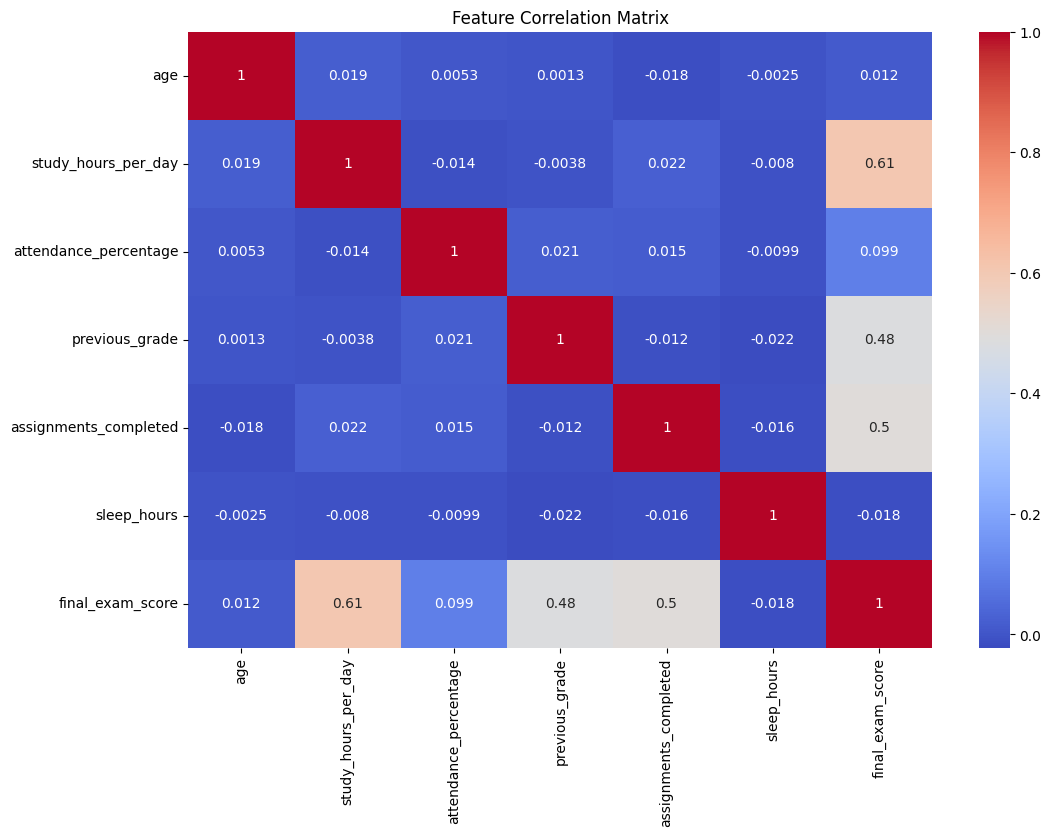

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")
plt.show()

In [7]:
df


,gender,age,study_hours_per_day,attendance_percentage,parental_education,internet_access,previous_grade,assignments_completed,sleep_hours,extracurricular_participation,final_exam_score,result
0,Male,17,4.86,68.65,Bachelor,Yes,88.08,7,6.96,No,86.15,Pass
1,Female,18,1.53,62.78,Master,No,74.01,2,8.82,No,52.87,Pass
2,Male,19,0.87,82.82,Bachelor,Yes,62.33,9,4.28,No,52.85,Pass
3,Male,17,5.99,90.26,Master,Yes,69.39,5,4.20,No,72.20,Pass
4,Male,15,0.64,64.42,Master,Yes,92.47,8,6.58,Yes,64.78,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Male,17,1.28,96.98,Bachelor,Yes,69.35,2,7.66,Yes,44.57,Pass
4996,Female,16,4.40,88.79,Master,Yes,51.45,6,7.00,No,62.22,Pass
4997,Male,18,5.20,64.46,Master,Yes,47.77,0,7.59,Yes,58.51,Pass
4998,Female,17,4.27,67.11,High School,Yes,81.74,1,6.36,No,63.61,Pass


## Train Model (Random Forest Example)

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])
df['internet_access'] = le.fit_transform(df['internet_access'])
df['extracurricular_participation'] = le.fit_transform(df['extracurricular_participation'])
df['parental_education'] = le.fit_transform(df['parental_education'])
df['result'] = le.fit_transform(df['result'])

## Actual vs Predicted Plot

MSE: 26.687264274679983


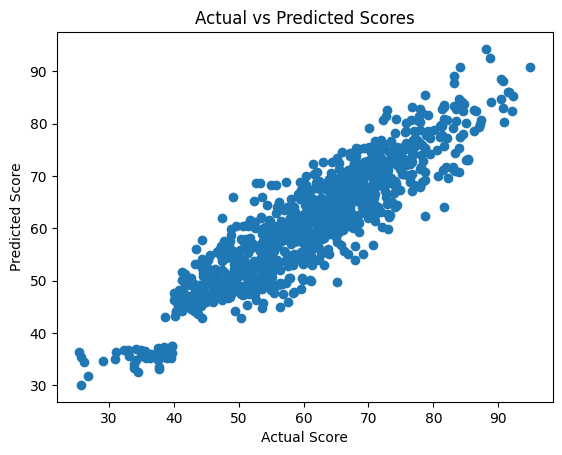

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load dataset

# Convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)

# Define features and target
X = df.drop("final_exam_score", axis=1)
y = df["final_exam_score"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, pred)
print("MSE:", mse)

# Plot
plt.scatter(y_test, pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Scores")
plt.show()

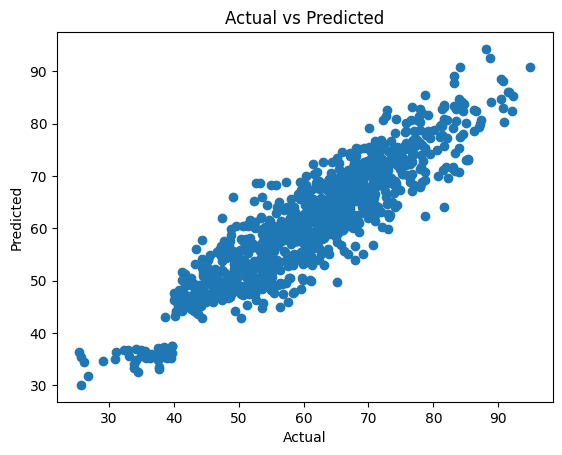

In [10]:
plt.figure()
plt.scatter(y_test, pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

In [11]:
import pickle
with open("result_prediction_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [12]:
df.columns

Index(['gender', 'age', 'study_hours_per_day', 'attendance_percentage',
       'parental_education', 'internet_access', 'previous_grade',
       'assignments_completed', 'sleep_hours', 'extracurricular_participation',
       'final_exam_score', 'result'],
      dtype='str')

In [14]:
df

,gender,age,study_hours_per_day,attendance_percentage,parental_education,internet_access,previous_grade,assignments_completed,sleep_hours,extracurricular_participation,final_exam_score,result
0,1,17,4.86,68.65,0,1,88.08,7,6.96,0,86.15,1
1,0,18,1.53,62.78,3,0,74.01,2,8.82,0,52.87,1
2,1,19,0.87,82.82,0,1,62.33,9,4.28,0,52.85,1
3,1,17,5.99,90.26,3,1,69.39,5,4.20,0,72.20,1
4,1,15,0.64,64.42,3,1,92.47,8,6.58,1,64.78,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1,17,1.28,96.98,0,1,69.35,2,7.66,1,44.57,1
4996,0,16,4.40,88.79,3,1,51.45,6,7.00,0,62.22,1
4997,1,18,5.20,64.46,3,1,47.77,0,7.59,1,58.51,1
4998,0,17,4.27,67.11,2,1,81.74,1,6.36,0,63.61,1
